# Evaluation2: Baseline vs Current With Recomputed Upper Bounds

This notebook loads two benchmark report JSON files:
- old master baseline report
- current local implementation report

It then recomputes upper-bound (ideal) benefits from overlaps and prescription doses using the same discrete DP logic as `benchmarks/run_benchmark.py`, and plots all three series per patient on a single chart.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "benchmarks" / "run_benchmark.py").exists():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory.")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from benchmarks.run_benchmark import (
    calc_standard_penalty,
    calc_upper_bound_treatment_discrete_dp,
    select_max_dose,
)
import adaptive_fractionation_overlap as afx

print(f"repo_root={repo_root}")


repo_root=C:\sources\Overlap_adaptfx


In [2]:
reports_dir = repo_root / "benchmarks" / "reports"

baseline_report = reports_dir / "master_baseline_20260306T131316Z.json"
if not baseline_report.exists():
    baseline_candidates = sorted(
        reports_dir.glob("master_baseline*.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not baseline_candidates:
        raise FileNotFoundError("No baseline report found (expected master_baseline*.json).")
    baseline_report = baseline_candidates[0]


def is_candidate_report(path: Path) -> bool:
    name = path.name.lower()
    if not name.endswith(".json"):
        return False
    if "master_baseline" in name:
        return False
    if "smoke" in name:
        return False
    if name.startswith("cfg_"):
        return False
    return True


current_candidates = sorted(
    [p for p in reports_dir.glob("*.json") if is_candidate_report(p)],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not current_candidates:
    raise FileNotFoundError("No candidate current report JSON files found in benchmarks/reports.")
current_report = current_candidates[0]

print(f"baseline_report={baseline_report}")
print(f"current_report={current_report}")


baseline_report=C:\sources\Overlap_adaptfx\benchmarks\reports\master_baseline_20260306T131316Z.json
current_report=C:\sources\Overlap_adaptfx\benchmarks\reports\belief_state_numba_jloop2_20260312T175800Z.json


In [3]:
def load_report(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def cases_to_df(report: dict) -> pd.DataFrame:
    rows = []
    for case in report.get("cases", []):
        rows.append(
            {
                "case_id": str(case["case_id"]),
                "patient_number": case["patient_number"],
                "overlaps": case["overlaps"],
                "prescription_dose": float(case["prescription_dose"]),
                "standard_penalty": float(case["standard_penalty"]),
                "benefit_af": float(case["benefit_af"]),
                "upper_bound_benefit": case.get("upper_bound_benefit"),
            }
        )

    return pd.DataFrame(rows)


baseline_data = load_report(baseline_report)
current_data = load_report(current_report)

baseline_df = cases_to_df(baseline_data).rename(columns={"benefit_af": "baseline_benefit"})
current_df = cases_to_df(current_data).rename(columns={"benefit_af": "current_benefit"})

merged = baseline_df.merge(
    current_df[["case_id", "current_benefit"]],
    on="case_id",
    how="inner",
    validate="one_to_one",
)

print(
    f"baseline_cases={len(baseline_df)} current_cases={len(current_df)} merged_cases={len(merged)}"
)

if len(merged) != len(baseline_df) or len(merged) != len(current_df):
    print("Warning: case sets differ between baseline and current reports.")

merged.head()


baseline_cases=58 current_cases=58 merged_cases=58


,case_id,patient_number,overlaps,prescription_dose,standard_penalty,baseline_benefit,upper_bound_benefit,current_benefit
0,1,1,"[2.02, 2.41, 3.04, 1.96, 5.3, 3.27]",33.0,-11.45766,1.360097,2.124160,1.360097
1,2,2,"[6.19, 10.97, 4.91, 7.65, 5.73, 5.87]",33.0,-25.18821,3.043710,3.312460,3.043710
2,3,3,"[9.08, 19.79, 6.02, 9.45, 19.59, 12.62]",33.0,-48.37599,15.681802,15.988740,15.681802
3,4,4,"[15.07, 19.81, 16.12, 22.630000000000003, 18.0...",33.0,-66.02853,-0.953220,2.182155,0.211217
4,5,5,"[17.150000000000002, 18.68, 18.35, 28.56000000...",33.0,-78.82698,-1.460458,3.983792,-1.460458


In [4]:
def compute_upper_bounds(report: dict, case_df: pd.DataFrame) -> pd.Series:
    cfg = report.get("config", {})
    n_fractions = int(cfg.get("number_of_fractions", 5))
    min_dose = float(cfg.get("min_dose", 6.0))
    dose_step = float(cfg.get("dose_step", 0.5))
    upper_cfg = dict(cfg.get("upper_bound", {}))
    upper_step = float(upper_cfg.get("step", dose_step))
    max_dose_policy = dict(cfg.get("max_dose_policy", {}))

    upper_benefits = {}
    for _, row in case_df.iterrows():
        case_id = str(row["case_id"])
        overlaps = [float(x) for x in row["overlaps"]]
        prescription_dose = float(row["prescription_dose"])

        mean_dose = prescription_dose / float(n_fractions)
        max_dose = select_max_dose(mean_dose, max_dose_policy)

        upper_doses, _ = calc_upper_bound_treatment_discrete_dp(
            overlaps=overlaps,
            prescription_dose=prescription_dose,
            number_of_fractions=n_fractions,
            min_dose=min_dose,
            max_dose=max_dose,
            step=upper_step,
            intercept=float(afx.INTERCEPT),
            slope=float(afx.SLOPE),
        )

        if upper_doses is None:
            upper_benefits[case_id] = np.nan
            continue

        upper_penalty = float(
            np.sum(
                afx.penalty_calc_single(
                    np.asarray(upper_doses, dtype=float),
                    min_dose,
                    np.asarray(overlaps[1:], dtype=float),
                    intercept=afx.INTERCEPT,
                    slope=afx.SLOPE,
                )
            )
        )
        standard_penalty = calc_standard_penalty(overlaps, mean_dose, min_dose)
        upper_benefits[case_id] = float(-upper_penalty - standard_penalty)

    return pd.Series(upper_benefits, name="upper_bound")


upper_series = compute_upper_bounds(baseline_data, merged)
merged = merged.merge(upper_series.to_frame(), left_on="case_id", right_index=True, how="left")

if "upper_bound_benefit" in merged.columns:
    comparison = merged["upper_bound_benefit"].astype(float)
    diff = merged["upper_bound"] - comparison
    print(
        "Computed vs stored baseline upper bound: "
        f"max_abs_diff={np.nanmax(np.abs(diff)):.6g}, "
        f"mean_diff={np.nanmean(diff):.6g}"
    )

merged[["case_id", "patient_number", "baseline_benefit", "current_benefit", "upper_bound"]].head()


Computed vs stored baseline upper bound: max_abs_diff=0, mean_diff=0


,case_id,patient_number,baseline_benefit,current_benefit,upper_bound
0,1,1,1.360097,1.360097,2.124160
1,2,2,3.043710,3.043710,3.312460
2,3,3,15.681802,15.681802,15.988740
3,4,4,-0.953220,0.211217,2.182155
4,5,5,-1.460458,-1.460458,3.983792


In [5]:
# Manual filter for plotting/summary.
# Edit this set to exclude patients from the visualization.
EXCLUDE_PATIENTS = {3, 14, 16, 49}

# Optional: exclude specific case IDs directly.
EXCLUDE_CASE_IDS = set()


def canonical_token(value):
    s = str(value).strip()
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
        return str(f)
    except Exception:
        return s


exclude_patient_tokens = {canonical_token(v) for v in EXCLUDE_PATIENTS}
exclude_case_tokens = {canonical_token(v) for v in EXCLUDE_CASE_IDS}

merged = merged.copy()
merged["patient_token"] = merged["patient_number"].map(canonical_token)
merged["case_token"] = merged["case_id"].map(canonical_token)

mask_visible = (
    ~merged["patient_token"].isin(exclude_patient_tokens)
    & ~merged["case_token"].isin(exclude_case_tokens)
)

merged_visible = merged.loc[mask_visible].copy()
removed_patients = sorted(set(merged.loc[~mask_visible, "patient_token"].tolist()))

print(f"excluded_patients={sorted(exclude_patient_tokens)}")
print(f"excluded_case_ids={sorted(exclude_case_tokens)}")
print(f"visible_cases={len(merged_visible)} / {len(merged)}")
print(f"removed_patient_numbers={removed_patients}")

if merged_visible.empty:
    raise ValueError("All cases were filtered out. Clear EXCLUDE_PATIENTS/EXCLUDE_CASE_IDS.")


excluded_patients=['14', '16', '3', '49']
excluded_case_ids=[]
visible_cases=54 / 58
removed_patient_numbers=['14', '16', '3', '49']


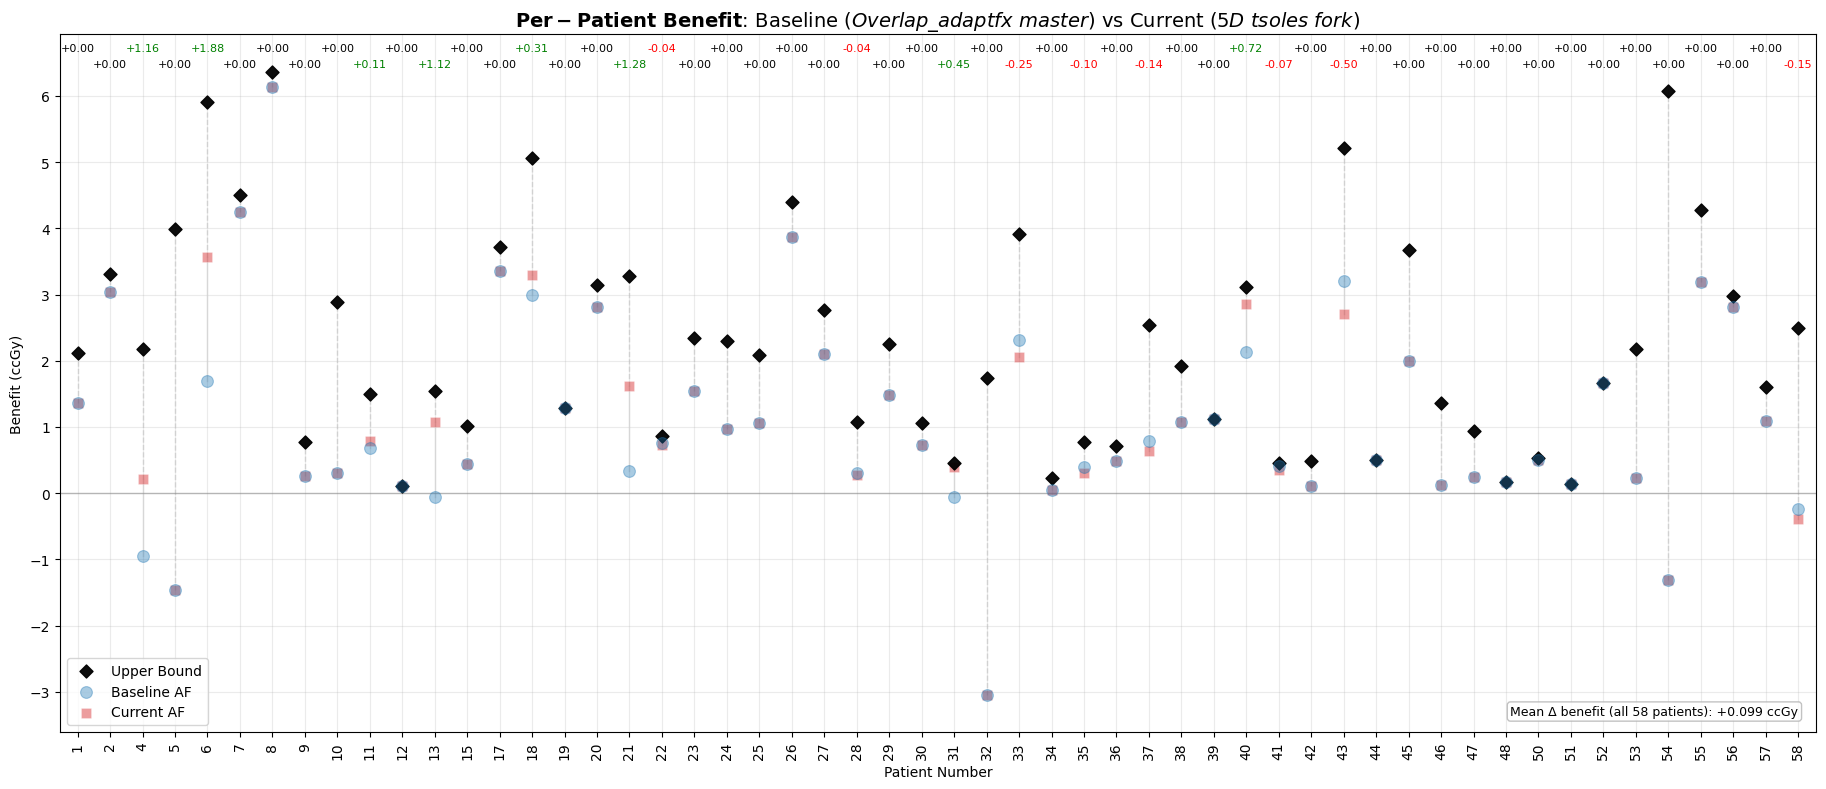

In [6]:
from matplotlib.ticker import MultipleLocator


def patient_sort_value(value):
    try:
        return (0, float(value))
    except Exception:
        return (1, str(value))


merged_plot = merged_visible.sort_values(
    by=["patient_number", "case_id"],
    key=lambda s: s.map(patient_sort_value),
).reset_index(drop=True)

x_spacing = 1.15
x = np.arange(len(merged_plot)) * x_spacing
patient_labels = merged_plot["patient_number"].astype(str).tolist()

# Mean delta computed on full cohort (includes excluded patients).
mean_delta_all = float((merged["current_benefit"] - merged["baseline_benefit"]).mean())
n_all = int(len(merged))

fig_width = max(16, len(merged_plot) * 0.34)
fig, ax = plt.subplots(figsize=(fig_width, 8))

ax.scatter(
    x,
    merged_plot["upper_bound"],
    color="black",
    s=44,
    alpha=0.95,
    marker="D",
    label="Upper Bound",
    zorder=4,
)
ax.scatter(
    x,
    merged_plot["baseline_benefit"],
    color="tab:blue",
    edgecolors="tab:blue",
    s=72,
    alpha=0.38,
    linewidths=0.8,
    label="Baseline AF",
    zorder=5,
)
ax.scatter(
    x,
    merged_plot["current_benefit"],
    color="tab:red",
    s=52,
    alpha=0.45,
    marker="s",
    edgecolors="white",
    linewidths=0.4,
    label="Current AF",
    zorder=3,
)

for i in range(len(merged_plot)):
    b = float(merged_plot.loc[i, "baseline_benefit"])
    c = float(merged_plot.loc[i, "current_benefit"])
    u = float(merged_plot.loc[i, "upper_bound"])

    ax.plot([x[i], x[i]], [b, c], color="lightgray", linewidth=1.0, alpha=0.8)
    if np.isfinite(u):
        ax.plot([x[i], x[i]], [max(b, c), u], color="silver", linestyle="--", linewidth=1, alpha=0.6)

# Auto-scale y-axis from visible data while guaranteeing all points are in-frame.
y_vals = merged_plot[["baseline_benefit", "current_benefit", "upper_bound"]].to_numpy(dtype=float).ravel()
y_vals = y_vals[np.isfinite(y_vals)]
if y_vals.size > 0:
    y_min = float(np.min(y_vals))
    y_max = float(np.max(y_vals))
    y_range = max(y_max - y_min, 1e-9)
    y_pad = max(0.20, y_range * 0.06)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

if len(x) > 0:
    edge_pad = 0.55 * x_spacing
    ax.set_xlim(x[0] - edge_pad, x[-1] + edge_pad)

# Per-patient delta labels (Current - Baseline) at the top, with alternating vertical offsets.
zero_tol = 1e-6
delta_vals = (merged_plot["current_benefit"] - merged_plot["baseline_benefit"]).to_numpy(dtype=float)
for i, xv in enumerate(x):
    delta = float(delta_vals[i])
    if abs(delta) <= zero_tol:
        delta = 0.0

    if delta > 0.0:
        txt_color = "green"
    elif delta < 0.0:
        txt_color = "red"
    else:
        txt_color = "black"

    y_offset = -6 if i % 2 == 0 else -18
    ax.annotate(
        f"{delta:+.2f}",
        xy=(xv, 1.0),
        xycoords=("data", "axes fraction"),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=8,
        color=txt_color,
    )

ax.axhline(y=0.0, color="gray", linestyle="-", linewidth=1, alpha=0.5)
ax.set_title(r"$\bf{Per-Patient\ Benefit}$: Baseline $\it{(Overlap\_adaptfx\ master)}$ vs Current $\it{(5D\ tsoles\ fork)}$", fontsize=14)
ax.set_xlabel("Patient Number")
ax.set_ylabel("Benefit (ccGy)")
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.set_xticks(x)
ax.set_xticklabels(patient_labels, rotation=90)
ax.grid(True, alpha=0.25)
ax.text(
    0.99,
    0.02,
    f"Mean Δ benefit (all {n_all} patients): {mean_delta_all:+.3f} ccGy",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="black",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.8},
)

ax.legend()
fig.tight_layout()
plt.show()


In [7]:
eps = 1e-9

gap_baseline = merged_plot["upper_bound"] - merged_plot["baseline_benefit"]
gap_current = merged_plot["upper_bound"] - merged_plot["current_benefit"]
gap_closure = (gap_baseline - gap_current) / np.maximum(np.abs(gap_baseline), eps)

summary = pd.DataFrame(
    {
        "metric": [
            "mean_baseline_benefit",
            "mean_current_benefit",
            "mean_upper_bound_benefit",
            "mean_gap_baseline",
            "mean_gap_current",
            "mean_gap_closure_normalized",
        ],
        "value": [
            float(np.nanmean(merged_plot["baseline_benefit"])),
            float(np.nanmean(merged_plot["current_benefit"])),
            float(np.nanmean(merged_plot["upper_bound"])),
            float(np.nanmean(gap_baseline)),
            float(np.nanmean(gap_current)),
            float(np.nanmean(gap_closure)),
        ],
    }
)

summary


,metric,value
0,mean_baseline_benefit,1.101807
1,mean_current_benefit,1.207985
2,mean_upper_bound_benefit,2.278833
3,mean_gap_baseline,1.177027
4,mean_gap_current,1.070848
5,mean_gap_closure_normalized,0.009536


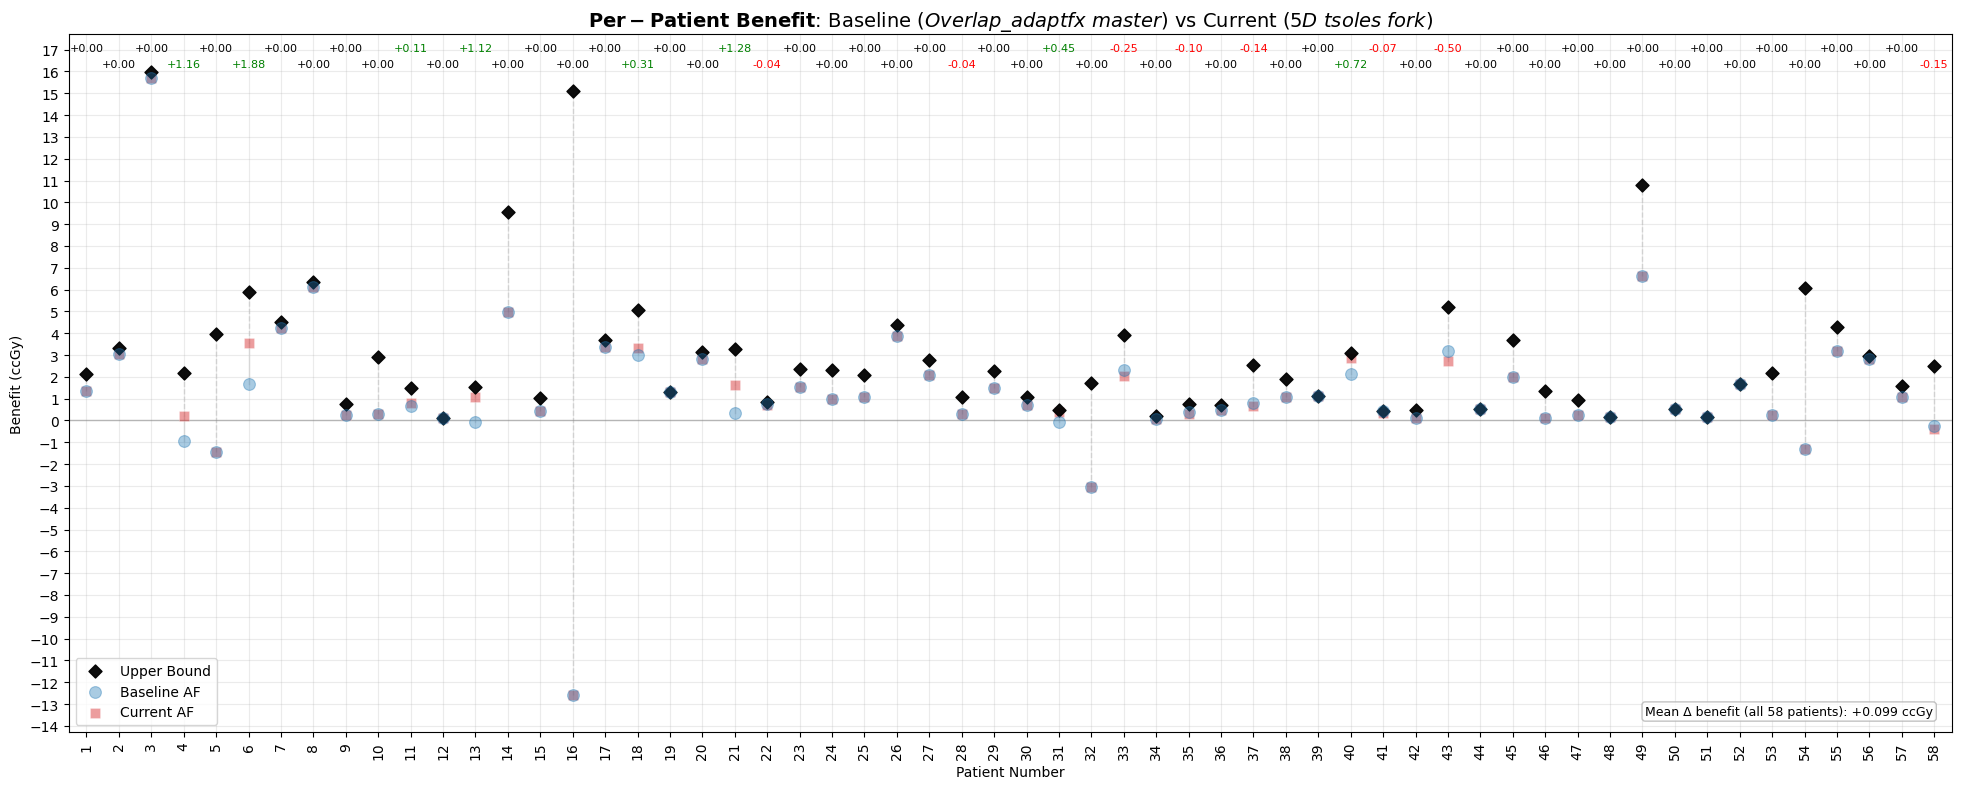

In [8]:
# Full-cohort version of the same plot (no patient exclusions).
from matplotlib.ticker import MultipleLocator


def patient_sort_value_all(value):
    try:
        return (0, float(value))
    except Exception:
        return (1, str(value))


merged_plot_all = merged.sort_values(
    by=["patient_number", "case_id"],
    key=lambda s: s.map(patient_sort_value_all),
).reset_index(drop=True)

x_spacing_all = 1.15
x_all = np.arange(len(merged_plot_all)) * x_spacing_all
patient_labels_all = merged_plot_all["patient_number"].astype(str).tolist()

mean_delta_all = float((merged["current_benefit"] - merged["baseline_benefit"]).mean())
n_all = int(len(merged))

fig_width_all = max(16, len(merged_plot_all) * 0.34)
fig_all, ax_all = plt.subplots(figsize=(fig_width_all, 8))

ax_all.scatter(
    x_all,
    merged_plot_all["upper_bound"],
    color="black",
    s=44,
    alpha=0.95,
    marker="D",
    label="Upper Bound",
    zorder=4,
)
ax_all.scatter(
    x_all,
    merged_plot_all["baseline_benefit"],
    color="tab:blue",
    edgecolors="tab:blue",
    s=72,
    alpha=0.38,
    linewidths=0.8,
    label="Baseline AF",
    zorder=5,
)
ax_all.scatter(
    x_all,
    merged_plot_all["current_benefit"],
    color="tab:red",
    s=52,
    alpha=0.45,
    marker="s",
    edgecolors="white",
    linewidths=0.4,
    label="Current AF",
    zorder=3,
)

for i in range(len(merged_plot_all)):
    b = float(merged_plot_all.loc[i, "baseline_benefit"])
    c = float(merged_plot_all.loc[i, "current_benefit"])
    u = float(merged_plot_all.loc[i, "upper_bound"])

    ax_all.plot([x_all[i], x_all[i]], [b, c], color="lightgray", linewidth=1.0, alpha=0.8)
    if np.isfinite(u):
        ax_all.plot([x_all[i], x_all[i]], [max(b, c), u], color="silver", linestyle="--", linewidth=1, alpha=0.6)

# Auto-scale y-axis from full-cohort data.
y_vals_all = merged_plot_all[["baseline_benefit", "current_benefit", "upper_bound"]].to_numpy(dtype=float).ravel()
y_vals_all = y_vals_all[np.isfinite(y_vals_all)]
if y_vals_all.size > 0:
    y_min_all = float(np.min(y_vals_all))
    y_max_all = float(np.max(y_vals_all))
    y_range_all = max(y_max_all - y_min_all, 1e-9)
    y_pad_all = max(0.20, y_range_all * 0.06)
    ax_all.set_ylim(y_min_all - y_pad_all, y_max_all + y_pad_all)

if len(x_all) > 0:
    edge_pad_all = 0.55 * x_spacing_all
    ax_all.set_xlim(x_all[0] - edge_pad_all, x_all[-1] + edge_pad_all)

# Per-patient delta labels (Current - Baseline) at the top, with alternating vertical offsets.
zero_tol = 1e-6
delta_vals_all = (merged_plot_all["current_benefit"] - merged_plot_all["baseline_benefit"]).to_numpy(dtype=float)
for i, xv in enumerate(x_all):
    delta = float(delta_vals_all[i])
    if abs(delta) <= zero_tol:
        delta = 0.0

    if delta > 0.0:
        txt_color = "green"
    elif delta < 0.0:
        txt_color = "red"
    else:
        txt_color = "black"

    y_offset = -6 if i % 2 == 0 else -18
    ax_all.annotate(
        f"{delta:+.2f}",
        xy=(xv, 1.0),
        xycoords=("data", "axes fraction"),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=8,
        color=txt_color,
    )

ax_all.axhline(y=0.0, color="gray", linestyle="-", linewidth=1, alpha=0.5)
ax_all.set_title(r"$\bf{Per-Patient\ Benefit}$: Baseline $\it{(Overlap\_adaptfx\ master)}$ vs Current $\it{(5D\ tsoles\ fork)}$", fontsize=14)
ax_all.set_xlabel("Patient Number")
ax_all.set_ylabel("Benefit (ccGy)")
ax_all.yaxis.set_major_locator(MultipleLocator(1))
ax_all.set_xticks(x_all)
ax_all.set_xticklabels(patient_labels_all, rotation=90)
ax_all.grid(True, alpha=0.25)
ax_all.text(
    0.99,
    0.02,
    f"Mean Δ benefit (all {n_all} patients): {mean_delta_all:+.3f} ccGy",
    transform=ax_all.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="black",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.8},
)

ax_all.legend()
fig_all.tight_layout()
plt.show()


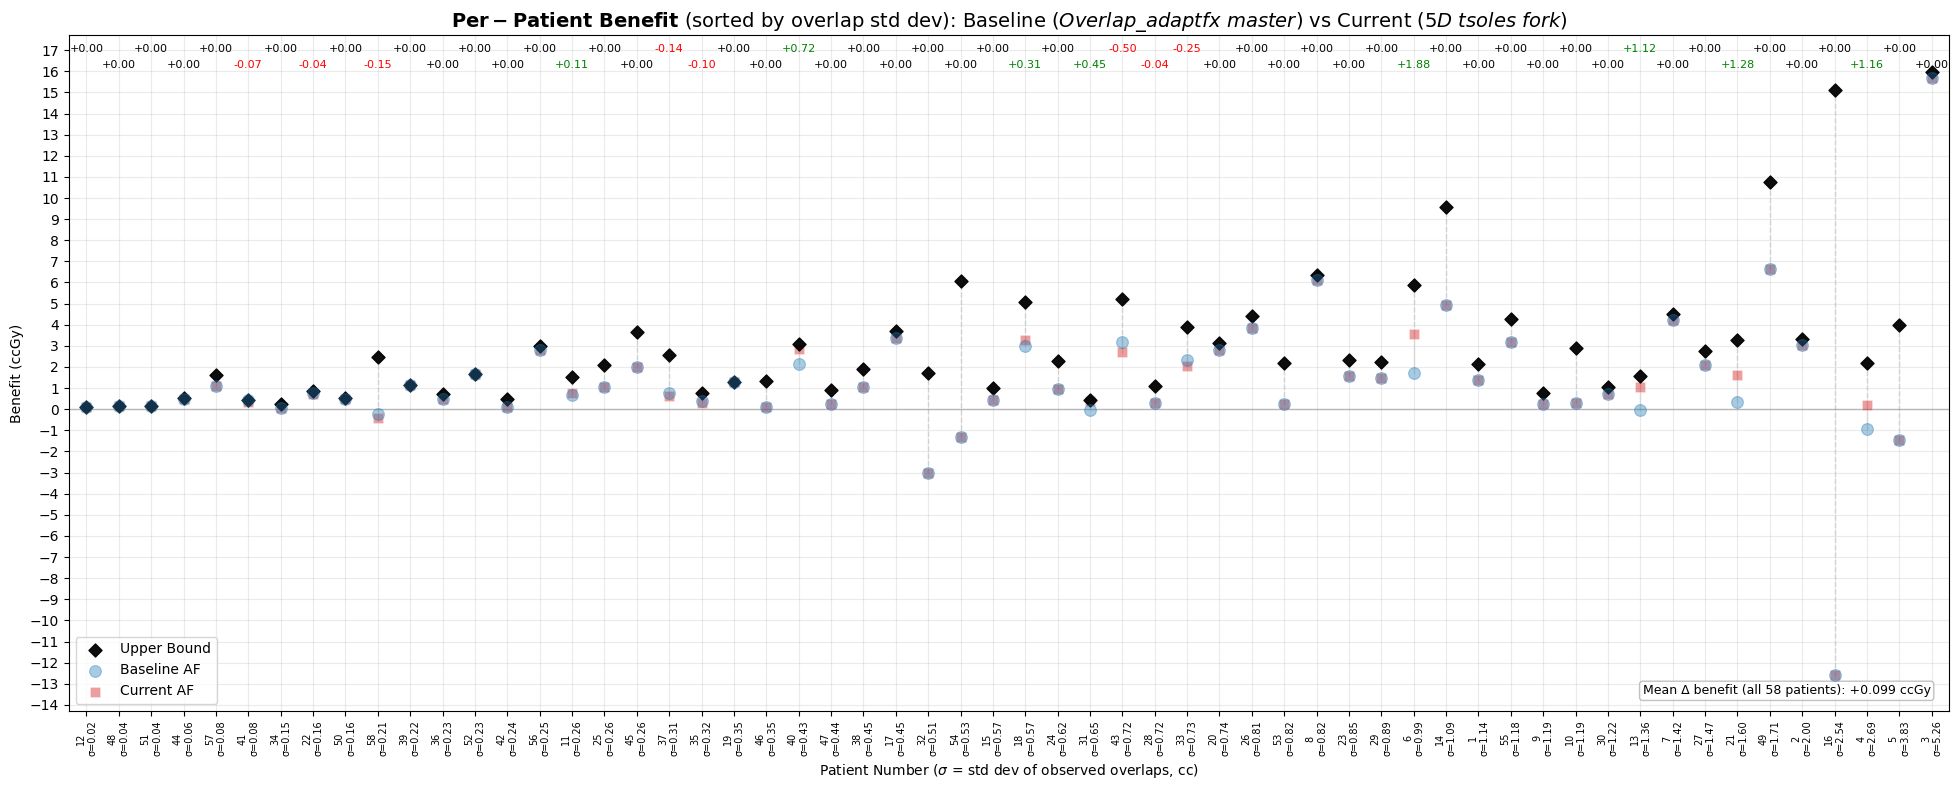

In [9]:
# Full-cohort plot ordered by overlap volume std dev (ascending).
from matplotlib.ticker import MultipleLocator

merged_std = merged.copy()
merged_std["overlap_std"] = merged_std["overlaps"].map(
    lambda v: float(np.std(v, ddof=0))
)

merged_plot_std = merged_std.sort_values("overlap_std").reset_index(drop=True)

x_spacing_std = 1.15
x_std = np.arange(len(merged_plot_std)) * x_spacing_std
# x-tick labels: patient number with std dev on second line
tick_labels_std = [
    str(row.patient_number) + "\n\u03c3=" + "{:.2f}".format(row.overlap_std)
    for row in merged_plot_std.itertuples()
]

mean_delta_std = float((merged["current_benefit"] - merged["baseline_benefit"]).mean())
n_std = int(len(merged))

fig_width_std = max(16, len(merged_plot_std) * 0.34)
fig_std, ax_std = plt.subplots(figsize=(fig_width_std, 8))

ax_std.scatter(
    x_std,
    merged_plot_std["upper_bound"],
    color="black",
    s=44,
    alpha=0.95,
    marker="D",
    label="Upper Bound",
    zorder=4,
)
ax_std.scatter(
    x_std,
    merged_plot_std["baseline_benefit"],
    color="tab:blue",
    edgecolors="tab:blue",
    s=72,
    alpha=0.38,
    linewidths=0.8,
    label="Baseline AF",
    zorder=5,
)
ax_std.scatter(
    x_std,
    merged_plot_std["current_benefit"],
    color="tab:red",
    s=52,
    alpha=0.45,
    marker="s",
    edgecolors="white",
    linewidths=0.4,
    label="Current AF",
    zorder=3,
)

for i in range(len(merged_plot_std)):
    b = float(merged_plot_std.loc[i, "baseline_benefit"])
    c = float(merged_plot_std.loc[i, "current_benefit"])
    u = float(merged_plot_std.loc[i, "upper_bound"])

    ax_std.plot([x_std[i], x_std[i]], [b, c], color="lightgray", linewidth=1.0, alpha=0.8)
    if np.isfinite(u):
        ax_std.plot([x_std[i], x_std[i]], [max(b, c), u], color="silver", linestyle="--", linewidth=1, alpha=0.6)

# Auto-scale y-axis.
y_vals_std = merged_plot_std[["baseline_benefit", "current_benefit", "upper_bound"]].to_numpy(dtype=float).ravel()
y_vals_std = y_vals_std[np.isfinite(y_vals_std)]
if y_vals_std.size > 0:
    y_min_std = float(np.min(y_vals_std))
    y_max_std = float(np.max(y_vals_std))
    y_range_std = max(y_max_std - y_min_std, 1e-9)
    y_pad_std = max(0.20, y_range_std * 0.06)
    ax_std.set_ylim(y_min_std - y_pad_std, y_max_std + y_pad_std)

if len(x_std) > 0:
    edge_pad_std = 0.55 * x_spacing_std
    ax_std.set_xlim(x_std[0] - edge_pad_std, x_std[-1] + edge_pad_std)

# Per-patient delta labels (Current - Baseline) at the top, with alternating vertical offsets.
zero_tol = 1e-6
delta_vals_std = (merged_plot_std["current_benefit"] - merged_plot_std["baseline_benefit"]).to_numpy(dtype=float)
for i, xv in enumerate(x_std):
    delta = float(delta_vals_std[i])
    if abs(delta) <= zero_tol:
        delta = 0.0

    txt_color = "green" if delta > 0.0 else ("red" if delta < 0.0 else "black")

    y_offset = -6 if i % 2 == 0 else -18
    ax_std.annotate(
        "{:+.2f}".format(delta),
        xy=(xv, 1.0),
        xycoords=("data", "axes fraction"),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=8,
        color=txt_color,
    )

ax_std.axhline(y=0.0, color="gray", linestyle="-", linewidth=1, alpha=0.5)
ax_std.set_title(
    r"$\bf{Per-Patient\ Benefit}$ (sorted by overlap std dev): "
    r"Baseline $\it{(Overlap\_adaptfx\ master)}$ vs Current $\it{(5D\ tsoles\ fork)}$",
    fontsize=14,
)
ax_std.set_xlabel(r"Patient Number ($\sigma$ = std dev of observed overlaps, cc)")
ax_std.set_ylabel("Benefit (ccGy)")
ax_std.yaxis.set_major_locator(MultipleLocator(1))
ax_std.set_xticks(x_std)
ax_std.set_xticklabels(tick_labels_std, rotation=90, fontsize=7)
ax_std.grid(True, alpha=0.25)
ax_std.text(
    0.99,
    0.02,
    "Mean \u0394 benefit (all {} patients): {:+.3f} ccGy".format(n_std, mean_delta_std),
    transform=ax_std.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="black",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.8},
)

ax_std.legend()
fig_std.tight_layout()
plt.show()
